# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# Step 1: Load and Understand the Dataset

Load the Dataset

In [2]:
df = pd.read_csv("adult_dataset.csv")

Display Basic Information

In [3]:
# Dataset Shape
print(df.shape)

(48842, 15)


In [4]:
# Column Names
print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')


In [5]:
# First 5 Rows
print(df.head())

    age         workclass  fnlwgt  education  education-num  \
0  39.0         State-gov   77516  Bachelors             13   
1  50.0  Self-emp-not-inc   83311  Bachelors             13   
2  38.0           Private  215646    HS-grad              9   
3  53.0           Private  234721       11th              7   
4  28.0           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0            40.0            NaN  <=50K  
1             0             0       

In [6]:
# Data Types
print(df.dtypes)

age               float64
workclass          object
fnlwgt              int64
education          object
education-num       int64
marital-status     object
occupation         object
relationship       object
race               object
sex                object
capital-gain        int64
capital-loss        int64
hours-per-week    float64
native-country     object
income             object
dtype: object


In [7]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [8]:
# Statistical Summary
print(df.describe())

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  46400.000000  4.884200e+04   48842.000000  48842.000000  48842.000000   
mean      38.679116  1.896641e+05      10.078089   1079.067626     87.502314   
std       13.952954  1.056040e+05       2.570973   7452.019058    403.004552   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.175505e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.781445e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.376420e+05      12.000000      0.000000      0.000000   
max      255.000000  1.490400e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    46400.000000  
mean        40.448599  
std         12.646992  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max        250.000000  


In [9]:
# Statistical Summary for Categorical Features
print(df.describe(include='object'))

       workclass education      marital-status      occupation relationship  \
count      45480     48842               48842           45485        48842   
unique         9        16                   7              15            6   
top      Private   HS-grad  Married-civ-spouse  Prof-specialty      Husband   
freq       32220     15784               22379            5854        19716   

         race    sex native-country income  
count   48842  48842          46137  48842  
unique      5      2             42      4  
top     White   Male  United-States  <=50K  
freq    41762  32650          41622  24720  


# Step 2: Missing Value Analysis & Data Quality Check

Missing Values Count

In [10]:
print(df.isnull().sum())

age               2442
workclass         3362
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        3357
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week    2442
native-country    2705
income               0
dtype: int64


Check for "?" Values in Every Column

In [11]:
for col in df.columns:
  print(col)
  print(df[col].value_counts().head())

age
age
33.0    1289
36.0    1289
35.0    1276
23.0    1258
31.0    1245
Name: count, dtype: int64
workclass
workclass
Private             32220
Self-emp-not-inc     3649
Local-gov            2973
State-gov            1877
?                    1763
Name: count, dtype: int64
fnlwgt
fnlwgt
203488    21
120277    19
190290    19
126569    18
125892    18
Name: count, dtype: int64
education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
Name: count, dtype: int64
education-num
education-num
9     15784
10    10878
13     8025
14     2657
11     2061
Name: count, dtype: int64
marital-status
marital-status
Married-civ-spouse    22379
Never-married         16117
Divorced               6633
Separated              1530
Widowed                1518
Name: count, dtype: int64
occupation
occupation
Prof-specialty     5854
Craft-repair       5791
Exec-managerial    5771
Adm-clerical       5329
Sales              5231
Name: count,

Replace "?" with NaN

In [12]:
df.replace("?", np.nan, inplace=True)

In [13]:
print(df.isnull().sum())

age               2442
workclass         5125
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        5115
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week    2442
native-country    3260
income               0
dtype: int64


Missing Percentage

In [14]:
missing_percentage = (df.isnull().sum()/len(df))*100
print(missing_percentage)

age                4.999795
workclass         10.493018
fnlwgt             0.000000
education          0.000000
education-num      0.000000
marital-status     0.000000
occupation        10.472544
relationship       0.000000
race               0.000000
sex                0.000000
capital-gain       0.000000
capital-loss       0.000000
hours-per-week     4.999795
native-country     6.674583
income             0.000000
dtype: float64


# Step 3: Handling Missing Values (Imputation)

Check Missing Values Before Imputation

In [15]:
print(df.isnull().sum())

age               2442
workclass         5125
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        5115
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week    2442
native-country    3260
income               0
dtype: int64


Numerical Imputation (Median)

In [16]:
numerical_cols = ['age', 'hours-per-week']

for col in numerical_cols:
  df[col] = df[col].fillna(df[col].median())

Categorical Imputation (Mode)

In [17]:
categorical_cols = ['workclass', 'occupation', 'native-country']

for col in categorical_cols:
  df[col] = df[col].fillna(df[col].mode()[0])

Verify Missing Vlaues Removed

In [18]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


Confirm Dataset Info Again

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  float64
 1   workclass       48842 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      48842 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  48842 non-null  float64
 13  native-country  48842 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


# Step 4: Outlier Detection & Treatment

## Step 4A: Visualize Numerical Distributions

Define numerical columns

In [20]:
numerical_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

Boxplot for Outlier Detection

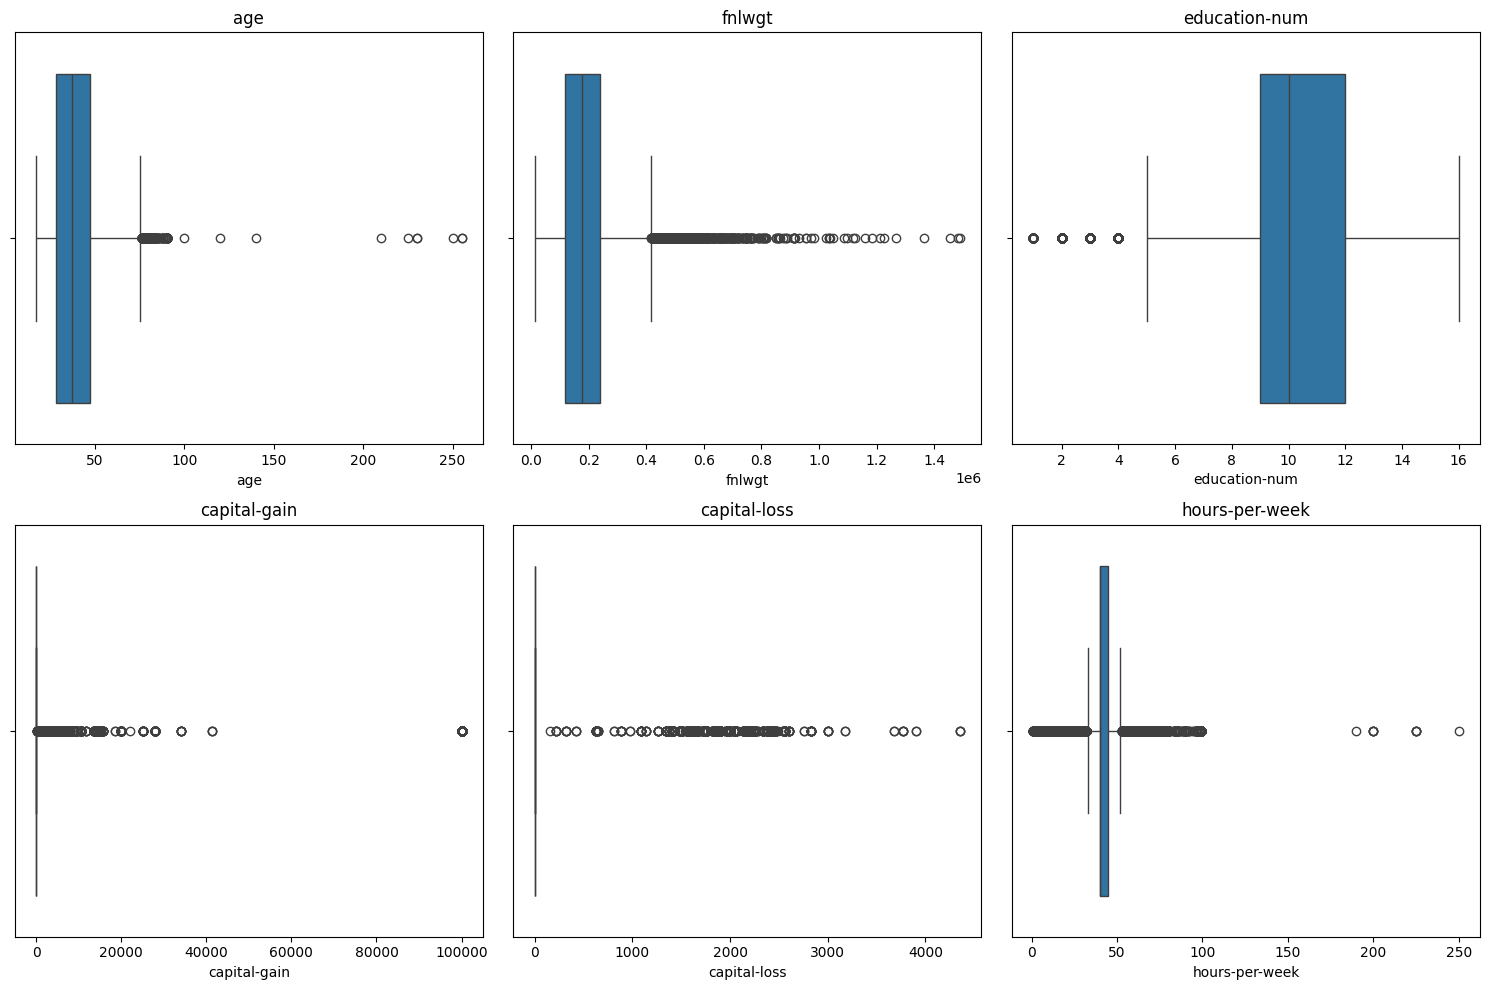

In [21]:
plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_features, 1):
  plt.subplot(2,3,i)
  sns.boxplot(x=df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

Histogram (Distribution Check)

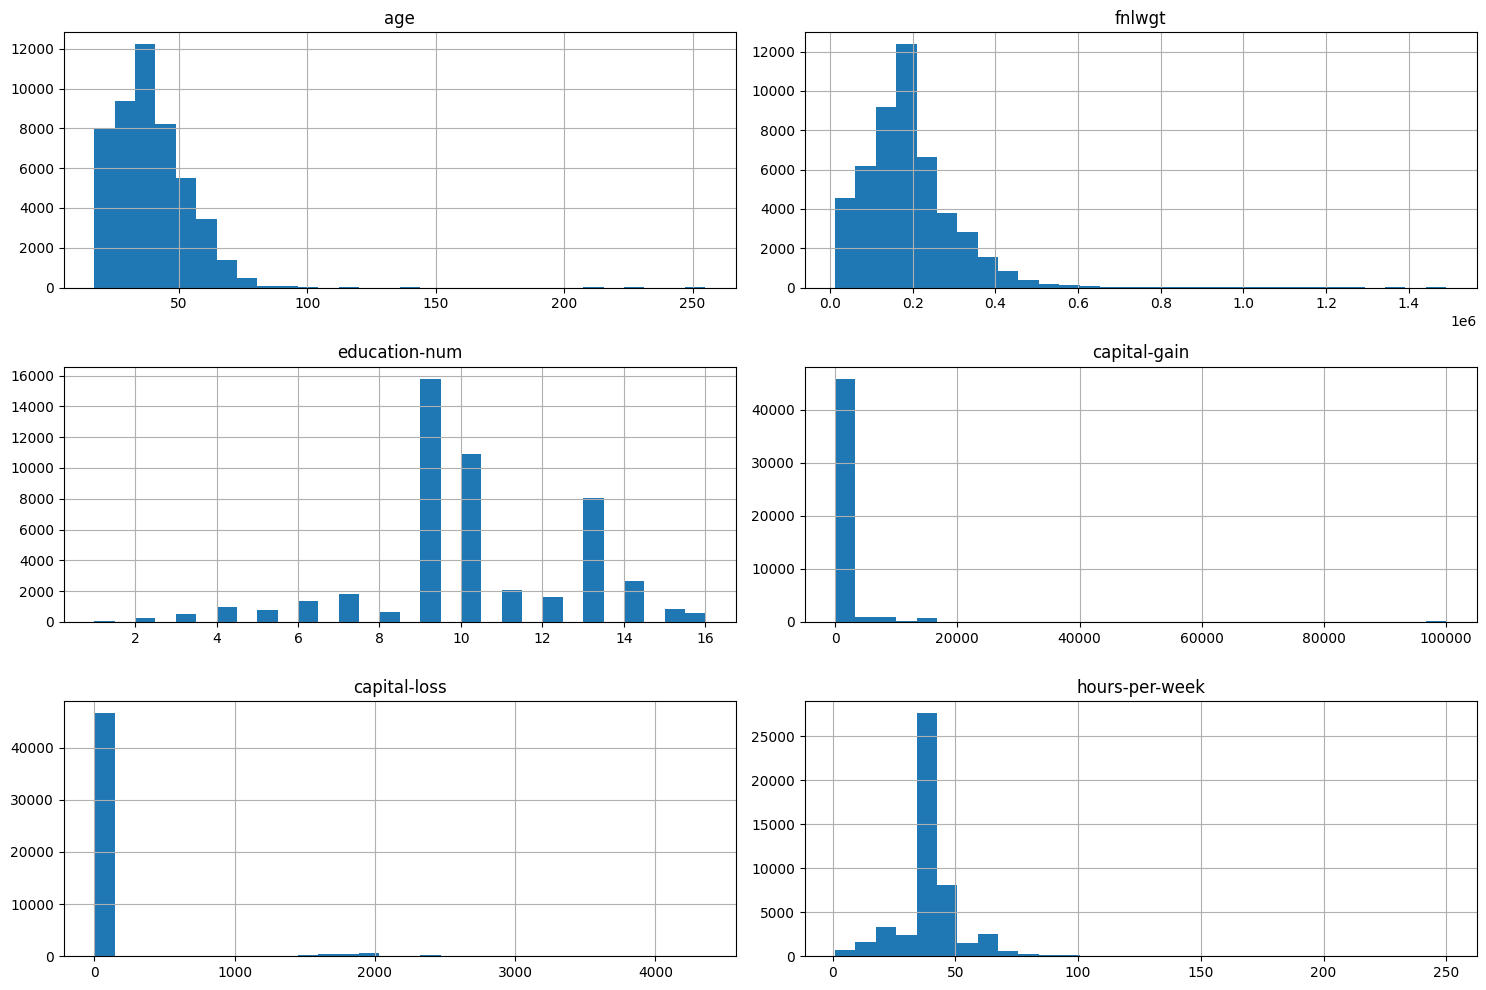

In [22]:
df[numerical_features].hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()

## Step 4B: Treat Outliers Using IQR Capping

Create Copy

In [23]:
df_cleaned = df.copy()

Define Columns to Treat

In [24]:
outlier_columns = ['age', 'hours-per-week']

Apply IQR Capping

In [25]:
for col in outlier_columns:

  Q1 = df_cleaned[col].quantile(0.25)
  Q3 = df_cleaned[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - (1.5 * IQR)
  upper_bound = Q3 + (1.5 * IQR)

  df_cleaned[col] = np.where(
      df_cleaned[col] < lower_bound,
      lower_bound,
      df_cleaned[col]
  )

  df_cleaned[col] = np.where(
      df_cleaned[col] > upper_bound,
      upper_bound,
      df_cleaned[col]
  )

Check Before/After Max Values

In [26]:
print(df[['age', 'hours-per-week']].describe())

                age  hours-per-week
count  48842.000000    48842.000000
mean      38.595164       40.426170
std       13.604587       12.327157
min       17.000000        1.000000
25%       28.000000       40.000000
50%       37.000000       40.000000
75%       47.000000       45.000000
max      255.000000      250.000000


In [27]:
print(df_cleaned[['age', 'hours-per-week']].describe())

                age  hours-per-week
count  48842.000000    48842.000000
mean      38.531387       41.129683
std       13.271160        6.033548
min       17.000000       32.500000
25%       28.000000       40.000000
50%       37.000000       40.000000
75%       47.000000       45.000000
max       75.500000       52.500000


Visualize Again

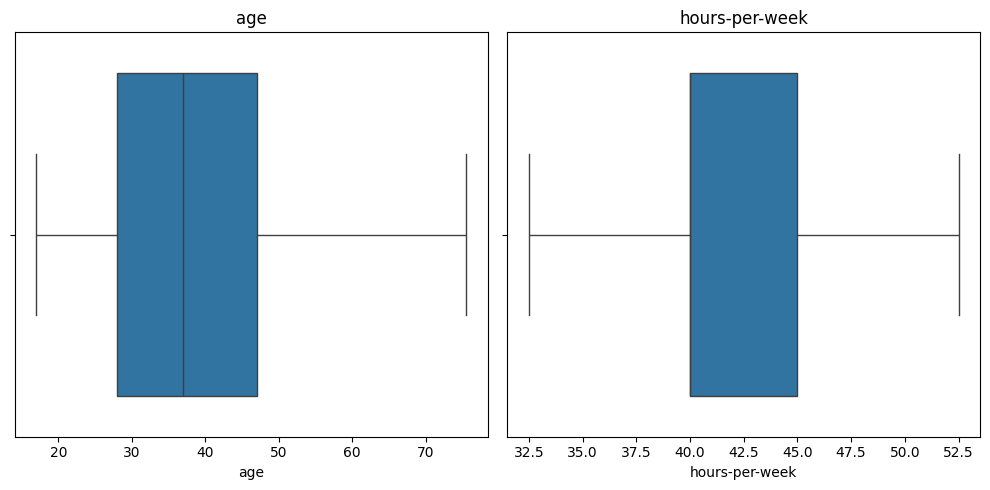

In [28]:
plt.figure(figsize=(10,5))

for i, col in enumerate(outlier_columns, 1):
  plt.subplot(1,2,i)
  sns.boxplot(x=df_cleaned[col])
  plt.title(col)

plt.tight_layout()
plt.show()

Drop fnlwgt

In [29]:
df_cleaned.drop('fnlwgt', axis=1, inplace=True)

In [30]:
print(df_cleaned.columns)

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')


# Step 5: Feature Selection

Create Backup of Income

In [31]:
income_column = df_cleaned['income']

Drop Redundant Columns

In [32]:
df_cleaned.drop(
    ['education-num', 'income'],
    axis=1,
    inplace=True
)

Check Remaining Columns

In [33]:
print(df_cleaned.columns)
print(df_cleaned.shape)

Index(['age', 'workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country'],
      dtype='object')
(48842, 12)


Separate Numerical & Categorical Features

In [34]:
numerical_cols = df_cleaned.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = df_cleaned.select_dtypes(
    include=['object']
).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['age', 'capital-gain', 'capital-loss', 'hours-per-week'], dtype='object')

Categorical Columns:
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')


# Step 6: Encoding Ctaegorical Variables

## Step 6A: Apply One-Hot Encoding

One-Hot Encode

In [35]:
df_encoded = pd.get_dummies(
    df_cleaned,
    columns=categorical_cols,
    drop_first=True
)

Check Shape

In [36]:
print(df_encoded.shape)

(48842, 95)


Check First Few Rows

In [37]:
print(df_encoded.head())

    age  capital-gain  capital-loss  hours-per-week  workclass_Local-gov  \
0  39.0          2174             0            40.0                False   
1  50.0             0             0            32.5                False   
2  38.0             0             0            40.0                False   
3  53.0             0             0            40.0                False   
4  28.0             0             0            40.0                False   

   workclass_Never-worked  workclass_Private  workclass_Self-emp-inc  \
0                   False              False                   False   
1                   False              False                   False   
2                   False               True                   False   
3                   False               True                   False   
4                   False               True                   False   

   workclass_Self-emp-not-inc  workclass_State-gov  ...  \
0                       False                 True 

Check Data Types

In [38]:
print(df_encoded.dtypes.value_counts())

bool       91
float64     2
int64       2
Name: count, dtype: int64


Confirm No Categorical Columns Remain

In [39]:
print(df_encoded.select_dtypes(include='object').columns)

Index([], dtype='object')


# Step 7: Feature Scaling

Convert Boolean to Integer

In [40]:
df_encoded = df_encoded.astype(int)

In [41]:
print(df_encoded.dtypes.value_counts())

int64    95
Name: count, dtype: int64


Scale Features

In [42]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)

Check Shape

In [43]:
print(scaled_data.shape)

(48842, 95)


Convert Back to DataFrame

In [44]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df_encoded.columns
)

Verify Scaling

In [45]:
print(scaled_df.describe())

                age  capital-gain  capital-loss  hours-per-week  \
count  4.884200e+04  4.884200e+04  4.884200e+04    4.884200e+04   
mean  -4.131570e-17  1.018345e-17 -9.892491e-18    1.686088e-16   
std    1.000010e+00  1.000010e+00  1.000010e+00    1.000010e+00   
min   -1.623417e+00 -1.448035e-01 -2.171271e-01   -1.485568e+00   
25%   -7.938987e-01 -1.448035e-01 -2.171271e-01   -1.648078e-01   
50%   -1.152020e-01 -1.448035e-01 -2.171271e-01   -1.648078e-01   
75%    6.389054e-01 -1.448035e-01 -2.171271e-01    6.606677e-01   
max    2.750406e+00  1.327438e+01  1.059179e+01    1.816333e+00   

       workclass_Local-gov  workclass_Never-worked  workclass_Private  \
count         4.884200e+04            4.884200e+04       4.884200e+04   
mean         -6.662884e-17           -2.618601e-18      -1.478055e-16   
std           1.000010e+00            1.000010e+00       1.000010e+00   
min          -2.545879e-01           -1.357577e-02      -1.802287e+00   
25%          -2.545879e-01     

# Step 8: Exploratory Analysis Before Clustering

## Step 8A: Correlation Heatmap

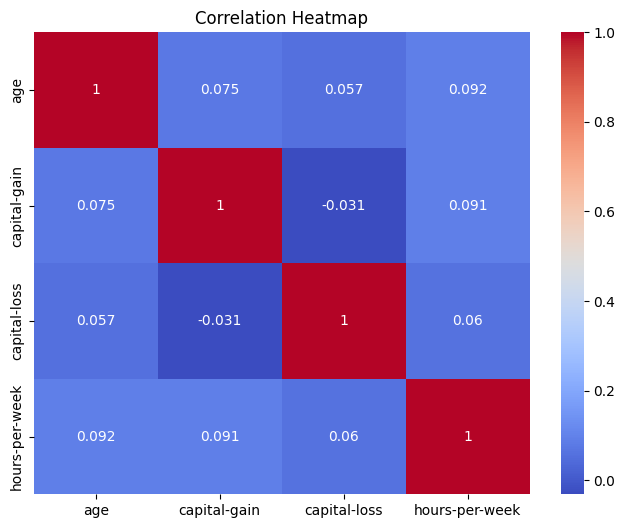

In [46]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_encoded[
        ['age',
         'capital-gain',
         'capital-loss',
         'hours-per-week']
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## Step 8B: PCA (Dimensionality Reduction)

Apply PCA

In [47]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

Convert to DataFrame

In [48]:
pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2']
)

Check Explained Variance

In [49]:
print(pca.explained_variance_ratio_)

[0.03468336 0.02681442]


Visualize PCA Scatterplot

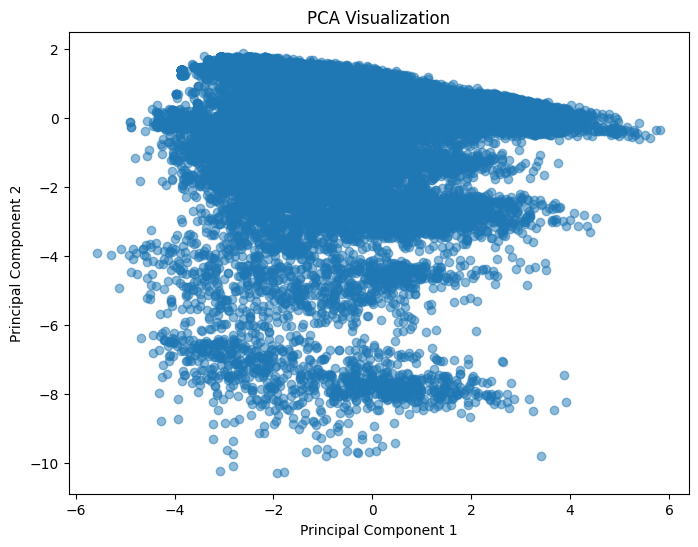

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.show()

# Step 9: Finding Optimal Number of Clusters (Elbow + Silhouette Score)

## Step 9A: Elbow Method

Calculate WCSS (Inertia)

In [51]:
wcss = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

Plot Elbow Curve

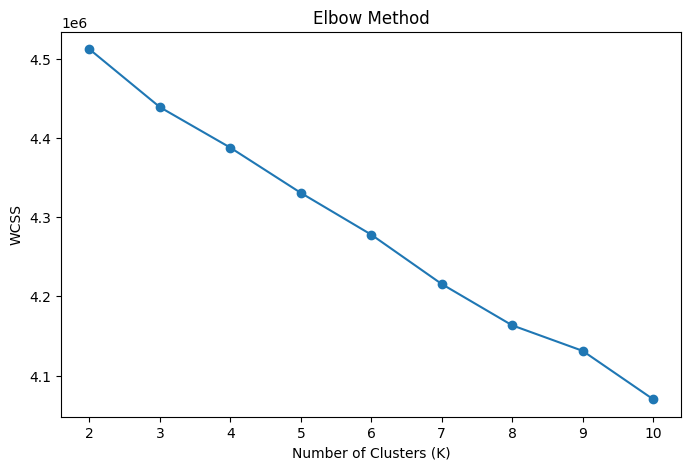

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

## Step 9B: Silhouette Score

Calculate Scores

In [53]:
silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    silhouette_scores.append(score)

Plot Silhouette Scores

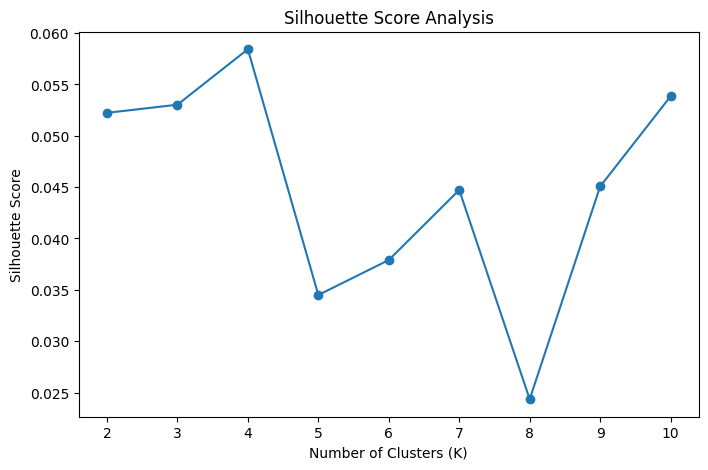

In [54]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")

plt.show()

Print Scores

In [55]:
for k, score in zip(range(2,11), silhouette_scores):
    print(f"K = {k}, Score = {score}")

K = 2, Score = 0.0522316163744783
K = 3, Score = 0.053023898970973427
K = 4, Score = 0.05842570231057188
K = 5, Score = 0.03449786048289507
K = 6, Score = 0.03790261541268421
K = 7, Score = 0.04472351476510147
K = 8, Score = 0.024351749284104506
K = 9, Score = 0.045061819506681415
K = 10, Score = 0.05383962286644657


# Step 10: Final KMeans Clustering

Train Final Model

In [56]:
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(
    scaled_data
)

Add Cluster Labels

In [57]:
# Add to PCA dataframe:
pca_df['Cluster'] = cluster_labels

In [58]:
# Add to original cleaned dataframe:
df_cleaned['Cluster'] = cluster_labels

Check Cluster Counts

In [59]:
print(df_cleaned['Cluster'].value_counts())

Cluster
3    21873
2    17638
0     8388
1      943
Name: count, dtype: int64


Visualize Clusters (PCA)

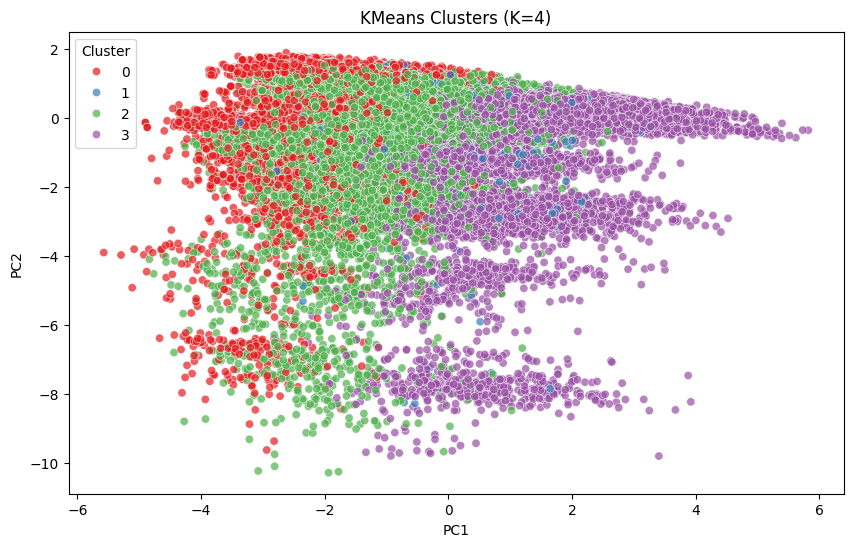

In [60]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    alpha=0.7
)

plt.title("KMeans Clusters (K=4)")
plt.show()

Cluster Centers Shape

In [61]:
print(final_kmeans.cluster_centers_.shape)

(4, 95)


# Step 11: Cluster Profiling & Interpretation

## Step 11A: Numerical Cluster Profile

In [62]:
numerical_summary = df_cleaned.groupby(
    'Cluster'
)[
    [
        'age',
        'capital-gain',
        'capital-loss',
        'hours-per-week'
    ]
].mean()

print(numerical_summary)

               age  capital-gain  capital-loss  hours-per-week
Cluster                                                       
0        25.476991    166.312232     40.704101       37.753577
1        38.787911    742.551432     86.488865       42.023860
2        39.011056    580.503005     66.827361       40.732764
3        43.139716   1845.638733    122.164404       42.705893


## Step 11B: Add Back Income for Interpretation

In [63]:
df_cleaned['income'] = income_column

## Step 11C: Income Distribution by Cluster

In [64]:
income_cluster = pd.crosstab(
    df_cleaned['Cluster'],
    df_cleaned['income'],
    normalize='index'
) * 100

print(income_cluster)

income       <=50K     <=50K.       >50K      >50K.
Cluster                                            
0        65.903672  32.904149   0.691464   0.500715
1        44.538706  24.390244  21.420997   9.650053
2        60.517065  30.910534   5.788638   2.783762
3        37.022814  18.255383  29.991313  14.730490


## Step 11D: Dominant Category Analysis

In [65]:
def top_category(column):

    return df_cleaned.groupby(
        'Cluster'
    )[column].agg(
        lambda x: x.mode()[0]
    )

In [66]:
categorical_features = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country'
]

for col in categorical_features:

    print(f"\n{col.upper()}")
    print(top_category(col))


WORKCLASS
Cluster
0      Private
1    Local-gov
2      Private
3      Private
Name: workclass, dtype: object

EDUCATION
Cluster
0    Some-college
1         HS-grad
2         HS-grad
3         HS-grad
Name: education, dtype: object

MARITAL-STATUS
Cluster
0         Never-married
1    Married-civ-spouse
2         Never-married
3    Married-civ-spouse
Name: marital-status, dtype: object

OCCUPATION
Cluster
0     Prof-specialty
1    Protective-serv
2     Prof-specialty
3     Prof-specialty
Name: occupation, dtype: object

RELATIONSHIP
Cluster
0        Own-child
1          Husband
2    Not-in-family
3          Husband
Name: relationship, dtype: object

RACE
Cluster
0    White
1    White
2    White
3    White
Name: race, dtype: object

SEX
Cluster
0      Male
1      Male
2    Female
3      Male
Name: sex, dtype: object

NATIVE-COUNTRY
Cluster
0    United-States
1    United-States
2    United-States
3    United-States
Name: native-country, dtype: object


In [67]:
df_cleaned['income'] = df_cleaned[
    'income'
].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

In [68]:
income_cluster = pd.crosstab(
    df_cleaned['Cluster'],
    df_cleaned['income'],
    normalize='index'
) * 100

print(income_cluster)

income       <=50K       >50K
Cluster                      
0        98.807821   1.192179
1        68.928950  31.071050
2        91.427600   8.572400
3        55.278197  44.721803


# Step 12: Agglomerative Clustering

Agglomerative clustering does not scale well to large datasets due to O(n²) memory complexity. Therefore, a representative sample combined with PCA was used for hierarchical clustering visualization.

Train Agglomerative Model

In [69]:
sample_size = 10000

indices = np.random.choice(
    len(pca_data),
    sample_size,
    replace=False
)

pca_sample = pca_data[indices]

In [70]:
agglo = AgglomerativeClustering(
    n_clusters=4
)

agglo_labels = agglo.fit_predict(pca_sample)

Build DataFrame for visualization

In [71]:
pca_sample_df = pd.DataFrame(
    pca_sample,
    columns=['PC1', 'PC2']
)

pca_sample_df['Agglo_Cluster'] = agglo_labels

PCA Visualization

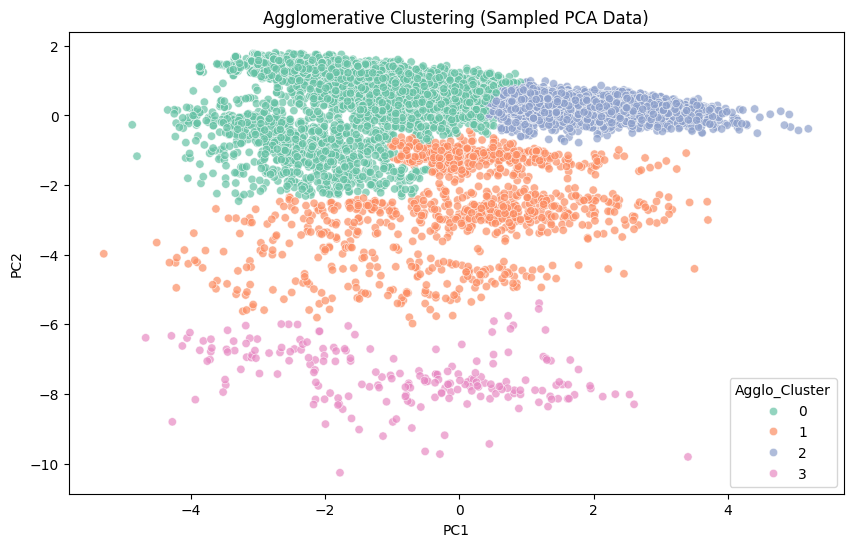

In [72]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_sample_df,
    x='PC1',
    y='PC2',
    hue='Agglo_Cluster',
    palette='Set2',
    alpha=0.7
)

plt.title("Agglomerative Clustering (Sampled PCA Data)")
plt.show()

Check cluster distribution

In [73]:
print(pd.Series(agglo_labels).value_counts())

0    4740
2    4053
1    1001
3     206
Name: count, dtype: int64


# Step 13: Interpretation, Insights & Policy Recommendations

## Cluster 0: Young Early-Career Population

### Characteristics
- Average age: ~25 years
- Mostly never married
- Lower working hours (~38/week)
- Education: Some college
- Relationship status: Own-child
- Very low capital gain
- Mostly lower-income population (>98% <=50K)

### Interpretation
This cluster represents young adults and early-career individuals, including students, recent graduates, and financially emerging workers.

### Recommended Policy Actions
**Upskilling Programs**
- Career readiness programs
- Technical skill development
- Internship and job placement initiatives

**Financial Aid / Inclusion Efforts**
- Education support
- Affordable housing support
- Youth employment schemes

## Cluster 1: Specialized Working Population

### Characteristics
- Average age: ~39 years
- Mostly married
- Higher work hours (~42/week)
- Occupation: Protective services
- Moderate higher-income percentage (~31%)

### Interpretation
This cluster appears to represent stable working-class professionals such as protective service employees and government workers.

### Recommended Policy Actions
**Tax Reform**
- Middle-income tax benefits
- Retirement savings incentives

**Upskilling Programs**
- Career advancement programs
- Leadership training

## Cluster 2: Middle-Class Workforce

### Characteristics
- Average age: ~39 years
- Mostly never married
- Moderate work hours (~41/week)
- Education: High school graduate
- Moderate professional occupations
- Mostly <=50K income (~91%)

### Interpretation
This cluster represents lower-middle or middle-income working adults with stable employment but limited financial growth.

### Recommended Policy Actions
**Upskilling Programs**
- Reskilling initiatives
- Digital literacy training
- Professional certification support

**Financial Inclusion**
- Financial literacy campaigns
- Savings and investment education

## Cluster 3: High-Earning Established Adults

### Characteristics
- Average age: ~43 years
- Highest capital gain and loss
- Highest working hours (~43/week)
- Mostly married
- Highest >50K population (~45%)

### Interpretation
This cluster represents financially established professionals and experienced working adults.

### Recommended Policy Actions
**Tax Reform**
- Retirement tax incentives
- Investment planning support

**Financial Planning**
- Wealth management education
- Retirement planning programs

## Key Findings

- Clustering successfully identified hidden socioeconomic groups without using income during training.
- Income patterns naturally emerged across clusters, validating meaningful segmentation.
- Younger and lower-income groups would benefit more from upskilling and financial inclusion programs.
- Higher-income established groups may benefit more from tax and investment-related policies.

# Step 14: KMeans vs Agglomerative Clustering Comparison

| Aspect | KMeans | Agglomerative |
|--------|---------|---------------|
| Speed | Faster | Slower |
| Scalability | Better for large datasets | Poor for large datasets |
| Cluster Shape | Best for spherical clusters | Can capture hierarchical relationships |
| Computational Cost | Low | High |
| Dataset Suitability | Better for Adult Census dataset | Used on sampled PCA data |

### Conclusion
KMeans was selected as the primary clustering algorithm because it handled the full dataset efficiently and produced meaningful clusters with reasonable silhouette scores.

Agglomerative clustering was used mainly for hierarchical comparison and visualization on sampled PCA data due to computational limitations.

# Step 15: Final Conclusion

This project successfully identified hidden socioeconomic groups in the U.S. adult population using unsupervised learning techniques.

KMeans clustering identified meaningful population segments based on demographics, education, occupation, and work habits without using income labels during training.

Cluster profiling revealed clear socioeconomic differences, with some groups showing lower earning potential and requiring upskilling or financial support, while others represented financially established populations who may benefit more from tax and investment policies.

The findings demonstrate how clustering techniques can help policymakers design targeted welfare, employment, and financial inclusion programs.